In [3]:
folder_path = "dataset"


### 1. Import

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

### 2. Column names and label map

In [5]:
columns = [
    "chest_acc_x", "chest_acc_y", "chest_acc_z",
    "ecg_1", "ecg_2",
    "ankle_acc_x", "ankle_acc_y", "ankle_acc_z",
    "ankle_gyro_x", "ankle_gyro_y", "ankle_gyro_z",
    "ankle_mag_x", "ankle_mag_y", "ankle_mag_z",
    "arm_acc_x", "arm_acc_y", "arm_acc_z",
    "arm_gyro_x", "arm_gyro_y", "arm_gyro_z",
    "arm_mag_x", "arm_mag_y", "arm_mag_z",
    "label"
]

label_map = {
    0: "null",
    1: "standing",
    2: "sitting_relaxing",
    3: "lying_down",
    4: "walking",
    5: "climbing_stairs",
    6: "waist_bends_forward",
    7: "frontal_arm_elevation",
    8: "knees_bending",
    9: "cycling",
    10: "jogging",
    11: "running",
    12: "jump_front_back"
}

### 3. Load all subject files

In [6]:
folder_path = "dataset"

all_dfs = []

for file in sorted(os.listdir(folder_path)):
    if file.startswith("mHealth_subject"):
        file_path = os.path.join(folder_path, file)

        subject_id = file.replace("mHealth_subject", "").replace(".log", "")
        subject_id = int(subject_id)

        df = pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
            names=columns,
            engine="python"
        )

        df["subject"] = subject_id
        all_dfs.append(df)

data = pd.concat(all_dfs, ignore_index=True)

print("Combined dataset shape:", data.shape)
data.head()

Combined dataset shape: (1215745, 25)


,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,label,subject
0,-9.8184,0.009971,0.29563,0.004186,0.004186,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-0.370000,-0.36327,0.29963,-8.6499,-4.5781,0.187760,-0.44902,-1.0103,0.034483,-2.35000,-1.610200,-0.030899,0,1
1,-9.8489,0.524040,0.37348,0.004186,0.016745,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-0.197990,-0.18151,0.58298,-8.6275,-4.3198,0.023595,-0.44902,-1.0103,0.034483,-2.16320,-0.882540,0.326570,0,1
2,-9.6602,0.181850,0.43742,0.016745,0.037677,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-0.374170,0.18723,0.43851,-8.5055,-4.2772,0.275720,-0.44902,-1.0103,0.034483,-1.61750,-0.165620,-0.030693,0,1
3,-9.6507,0.214220,0.24033,0.079540,0.117220,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-0.017271,0.18366,0.57571,-8.6279,-4.3163,0.367520,-0.45686,-1.0082,0.025862,-1.07710,0.006945,-0.382620,0,1
4,-9.7030,0.303890,0.31156,0.221870,0.205130,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-0.374390,-0.54671,0.44586,-8.7008,-4.1459,0.407290,-0.45686,-1.0082,0.025862,-0.53684,0.175900,-1.095500,0,1


### 4. Overview

In [7]:
print("First 5 rows:")
display(data.head())

print("\nDataset info:")
print(data.info())

print("\nMissing values per column:")
display(data.isnull().sum())

print("\nDuplicate rows:", data.duplicated().sum())

print("\nUnique labels:")
print(sorted(data["label"].unique()))

print("\nLabel counts:")
display(data["label"].value_counts().sort_index())

First 5 rows:


,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,label,subject
0,-9.8184,0.009971,0.29563,0.004186,0.004186,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-0.370000,-0.36327,0.29963,-8.6499,-4.5781,0.187760,-0.44902,-1.0103,0.034483,-2.35000,-1.610200,-0.030899,0,1
1,-9.8489,0.524040,0.37348,0.004186,0.016745,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-0.197990,-0.18151,0.58298,-8.6275,-4.3198,0.023595,-0.44902,-1.0103,0.034483,-2.16320,-0.882540,0.326570,0,1
2,-9.6602,0.181850,0.43742,0.016745,0.037677,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-0.374170,0.18723,0.43851,-8.5055,-4.2772,0.275720,-0.44902,-1.0103,0.034483,-1.61750,-0.165620,-0.030693,0,1
3,-9.6507,0.214220,0.24033,0.079540,0.117220,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-0.017271,0.18366,0.57571,-8.6279,-4.3163,0.367520,-0.45686,-1.0082,0.025862,-1.07710,0.006945,-0.382620,0,1
4,-9.7030,0.303890,0.31156,0.221870,0.205130,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-0.374390,-0.54671,0.44586,-8.7008,-4.1459,0.407290,-0.45686,-1.0082,0.025862,-0.53684,0.175900,-1.095500,0,1



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215745 entries, 0 to 1215744
Data columns (total 25 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   chest_acc_x   1215745 non-null  float64
 1   chest_acc_y   1215745 non-null  float64
 2   chest_acc_z   1215745 non-null  float64
 3   ecg_1         1215745 non-null  float64
 4   ecg_2         1215745 non-null  float64
 5   ankle_acc_x   1215745 non-null  float64
 6   ankle_acc_y   1215745 non-null  float64
 7   ankle_acc_z   1215745 non-null  float64
 8   ankle_gyro_x  1215745 non-null  float64
 9   ankle_gyro_y  1215745 non-null  float64
 10  ankle_gyro_z  1215745 non-null  float64
 11  ankle_mag_x   1215745 non-null  float64
 12  ankle_mag_y   1215745 non-null  float64
 13  ankle_mag_z   1215745 non-null  float64
 14  arm_acc_x     1215745 non-null  float64
 15  arm_acc_y     1215745 non-null  float64
 16  arm_acc_z     1215745 non-null  float64
 17  arm_gyro_x  

chest_acc_x     0
chest_acc_y     0
chest_acc_z     0
ecg_1           0
ecg_2           0
ankle_acc_x     0
ankle_acc_y     0
ankle_acc_z     0
ankle_gyro_x    0
ankle_gyro_y    0
ankle_gyro_z    0
ankle_mag_x     0
ankle_mag_y     0
ankle_mag_z     0
arm_acc_x       0
arm_acc_y       0
arm_acc_z       0
arm_gyro_x      0
arm_gyro_y      0
arm_gyro_z      0
arm_mag_x       0
arm_mag_y       0
arm_mag_z       0
label           0
subject         0
dtype: int64


Duplicate rows: 0

Unique labels:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Label counts:


label
0     872550
1      30720
2      30720
3      30720
4      30720
5      30720
6      28315
7      29441
8      29337
9      30720
10     30720
11     30720
12     10342
Name: count, dtype: int64

### 5. Add readable activity names

In [8]:
data["activity"] = data["label"].map(label_map)

display(
    data[["label", "activity"]]
    .drop_duplicates()
    .sort_values("label")
    .reset_index(drop=True)
)

,label,activity
0,0,null
1,1,standing
2,2,sitting_relaxing
3,3,lying_down
4,4,walking
5,5,climbing_stairs
6,6,waist_bends_forward
7,7,frontal_arm_elevation
8,8,knees_bending
9,9,cycling


### 6. Remove the null class (label 0)

In [9]:
df_clean = data[data["label"] != 0].copy()

print("Original shape:", data.shape)
print("Shape after removing label 0:", df_clean.shape)

print("\nCleaned label counts:")
display(df_clean["label"].value_counts().sort_index())

Original shape: (1215745, 26)
Shape after removing label 0: (343195, 26)

Cleaned label counts:


label
1     30720
2     30720
3     30720
4     30720
5     30720
6     28315
7     29441
8     29337
9     30720
10    30720
11    30720
12    10342
Name: count, dtype: int64

### 7. Activity distribution plot

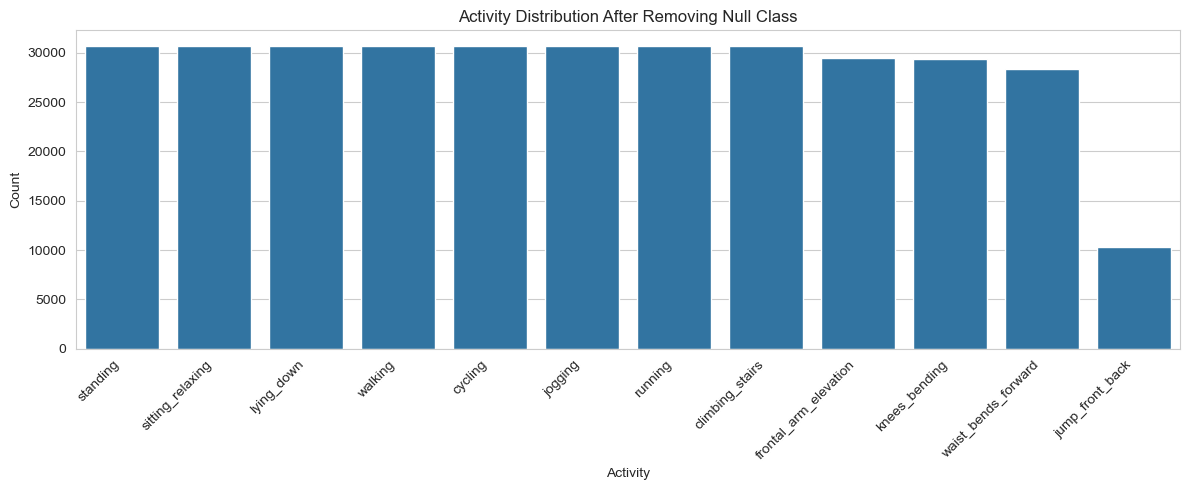

In [10]:
plt.figure(figsize=(12, 5))
sns.countplot(
    data=df_clean,
    x="activity",
    order=df_clean["activity"].value_counts().index
)
plt.xticks(rotation=45, ha="right")
plt.title("Activity Distribution After Removing Null Class")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 8. Summary statistics

In [11]:
display(df_clean.describe().T)

,count,mean,std,min,25%,50%,75%,max
chest_acc_x,343195.0,-7.485271,5.701949,-22.4380,-9.707100,-8.800300,-5.117400,19.0940
chest_acc_y,343195.0,-0.140923,2.799380,-20.1880,-1.294300,-0.292570,0.984775,20.9270
chest_acc_z,343195.0,-0.938418,4.611164,-18.4010,-3.686550,-0.881070,1.092650,26.1960
ecg_1,343195.0,0.003649,0.839074,-8.6196,-0.213500,-0.071167,0.163270,8.5065
ecg_2,343195.0,-0.008048,0.857724,-8.6196,-0.171640,-0.046049,0.138150,8.5191
ankle_acc_x,343195.0,1.805184,4.214175,-22.1460,0.159875,1.372500,2.924450,20.0240
ankle_acc_y,343195.0,-9.061487,5.200389,-19.6190,-10.063000,-9.597700,-7.549800,21.1610
ankle_acc_z,343195.0,-0.701985,6.457622,-19.3730,-3.494350,0.340070,1.819300,25.0150
ankle_gyro_x,343195.0,0.101167,0.458913,-1.7792,-0.345080,0.204080,0.487940,1.7106
ankle_gyro_y,343195.0,-0.549942,0.434721,-2.6604,-0.810510,-0.688560,-0.487800,1.7523


### 9. Check subject distribution

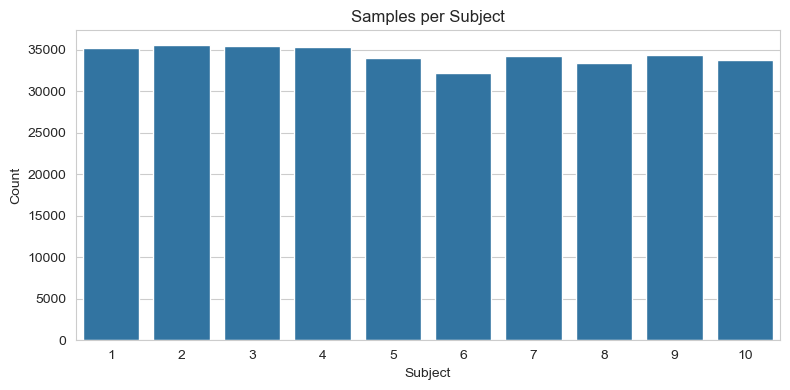

In [12]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x="subject")
plt.title("Samples per Subject")
plt.xlabel("Subject")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 10. Example signal plot for one subject

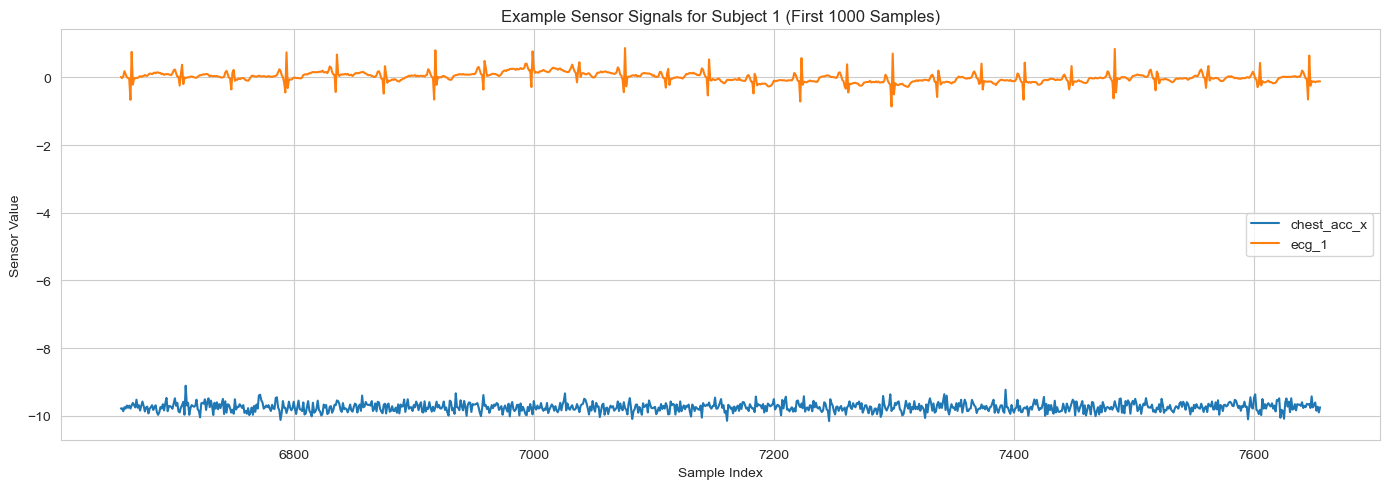

In [13]:
subject_1 = df_clean[df_clean["subject"] == 1].copy()

plt.figure(figsize=(14, 5))
plt.plot(subject_1.index[:1000], subject_1["chest_acc_x"].iloc[:1000], label="chest_acc_x")
plt.plot(subject_1.index[:1000], subject_1["ecg_1"].iloc[:1000], label="ecg_1")
plt.title("Example Sensor Signals for Subject 1 (First 1000 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Sensor Value")
plt.legend()
plt.tight_layout()
plt.show()

### 11. Boxplots for selected columns

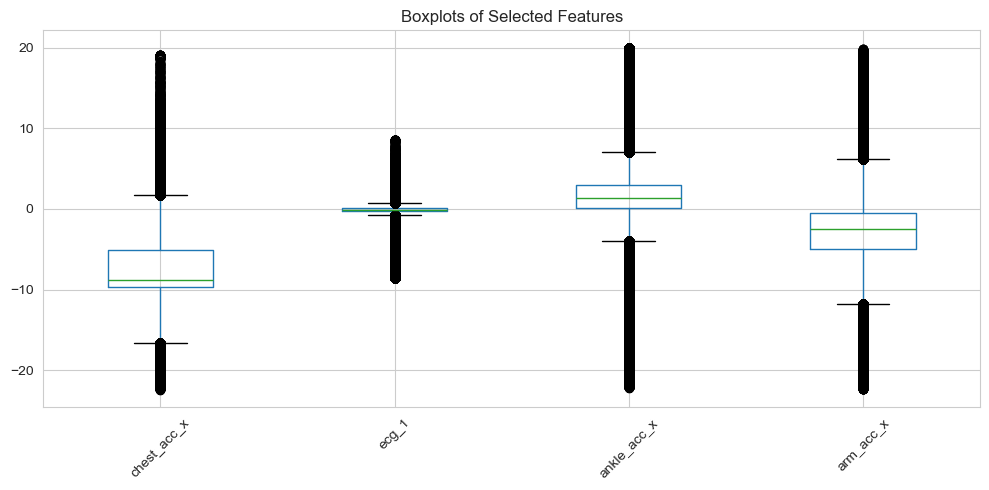

In [14]:
selected_cols = ["chest_acc_x", "ecg_1", "ankle_acc_x", "arm_acc_x"]

plt.figure(figsize=(10, 5))
df_clean[selected_cols].boxplot()
plt.title("Boxplots of Selected Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 12. Correlation heatmap

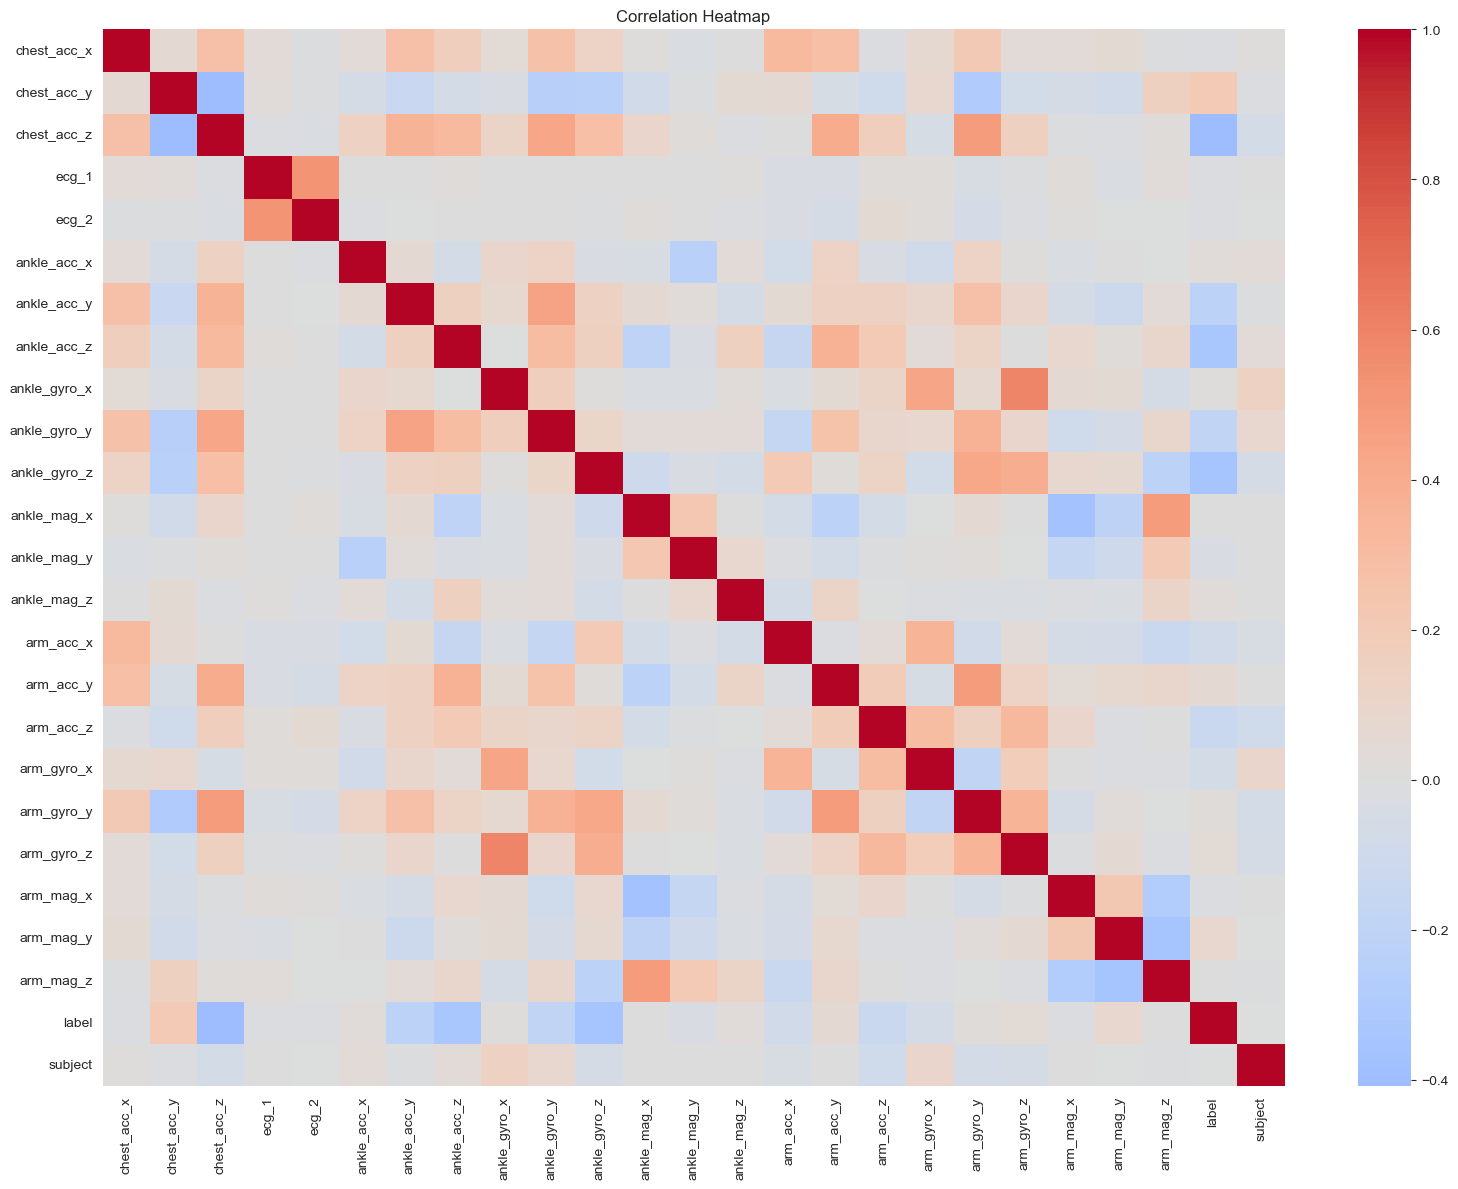

In [15]:
numeric_df = df_clean.drop(columns=["activity"])
corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### 13. Prepare X and y

In [16]:
X = df_clean.drop(columns=["label", "activity"])
y = df_clean["label"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (343195, 24)
Target shape: (343195,)


### 14. Scale features

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled X shape:", X_scaled.shape)

Scaled X shape: (343195, 24)


### 15. Subject-wise split

In [18]:
from sklearn.model_selection import GroupShuffleSplit

X = df_clean.drop(columns=["label", "activity"])
y = df_clean["label"]
groups = df_clean["subject"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train subjects:", sorted(df_clean.iloc[train_idx]["subject"].unique()))
print("Test subjects:", sorted(df_clean.iloc[test_idx]["subject"].unique()))

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train subjects: [np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10)]
Test subjects: [np.int64(2), np.int64(9)]
Train shape: (273309, 24)
Test shape: (69886, 24)


### 16. Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 17. KNN

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

C:\Users\mukta\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\mukta\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\mukta\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\mukta\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^

KNN Accuracy: 0.6801505308645508

Classification Report:

              precision    recall  f1-score   support

           1       0.29      0.03      0.06      6144
           2       0.99      0.50      0.67      6144
           3       1.00      0.50      0.67      6144
           4       0.58      0.98      0.73      6144
           5       0.46      0.89      0.61      6144
           6       0.89      0.55      0.68      6041
           7       0.53      0.92      0.67      6195
           8       0.72      0.85      0.78      6399
           9       0.99      1.00      0.99      6144
          10       0.65      0.69      0.67      6144
          11       0.81      0.72      0.76      6144
          12       0.83      0.27      0.41      2099

    accuracy                           0.68     69886
   macro avg       0.73      0.66      0.64     69886
weighted avg       0.72      0.68      0.65     69886



### 18. KNN Confusion Matrix

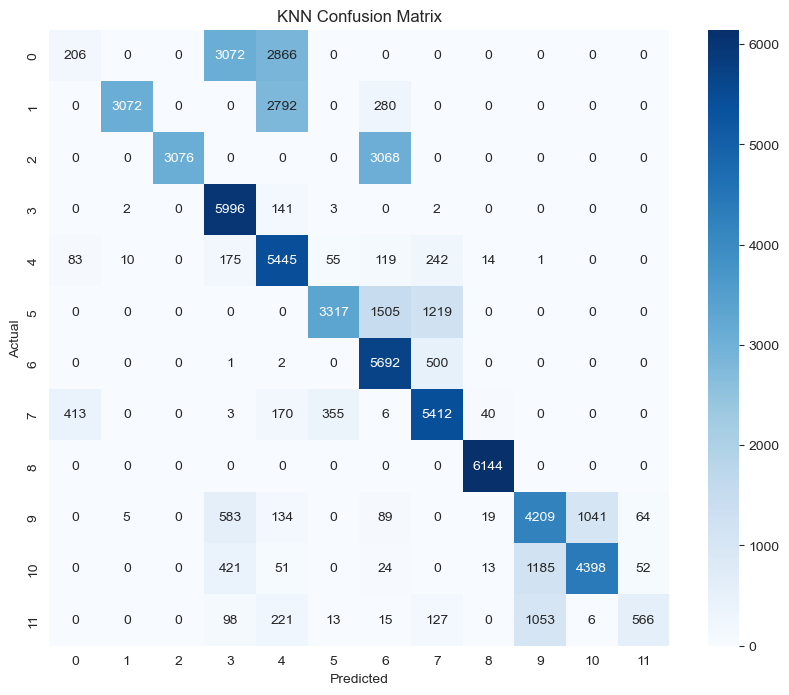

In [21]:
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 19. Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.787096127979853

Classification Report:

              precision    recall  f1-score   support

           1       0.99      0.97      0.98      6144
           2       0.00      0.00      0.00      6144
           3       1.00      0.98      0.99      6144
           4       0.99      0.98      0.99      6144
           5       0.58      0.99      0.73      6144
           6       0.98      0.48      0.65      6041
           7       0.64      0.94      0.76      6195
           8       0.63      0.84      0.72      6399
           9       1.00      1.00      1.00      6144
          10       0.74      0.62      0.68      6144
          11       0.72      0.91      0.81      6144
          12       0.79      0.59      0.67      2099

    accuracy                           0.79     69886
   macro avg       0.76      0.78      0.75     69886
weighted avg       0.75      0.79      0.75     69886



C:\Users\mukta\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mukta\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mukta\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 20. Random Forest Confusion Matrix

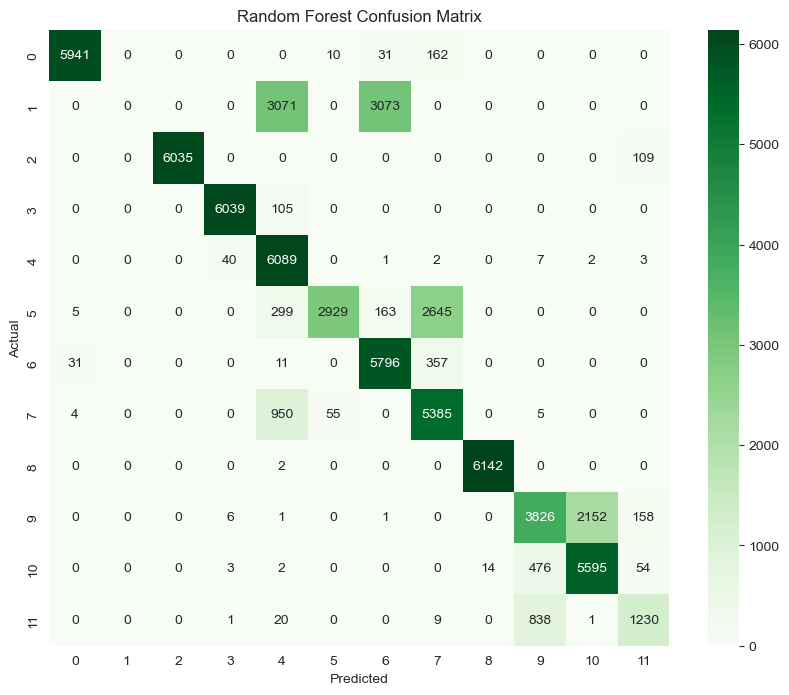

In [23]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10,8))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 21. Random Forest feature importance

In [24]:
feature_names = X.columns

importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(feat_imp.head(15))

,Feature,Importance
2,chest_acc_z,0.079633
7,ankle_acc_z,0.065710
18,arm_gyro_y,0.065596
17,arm_gyro_x,0.060259
15,arm_acc_y,0.057898
16,arm_acc_z,0.056716
0,chest_acc_x,0.056524
11,ankle_mag_x,0.056381
10,ankle_gyro_z,0.054258
8,ankle_gyro_x,0.054160


### 22. Top 15 feature importance plot

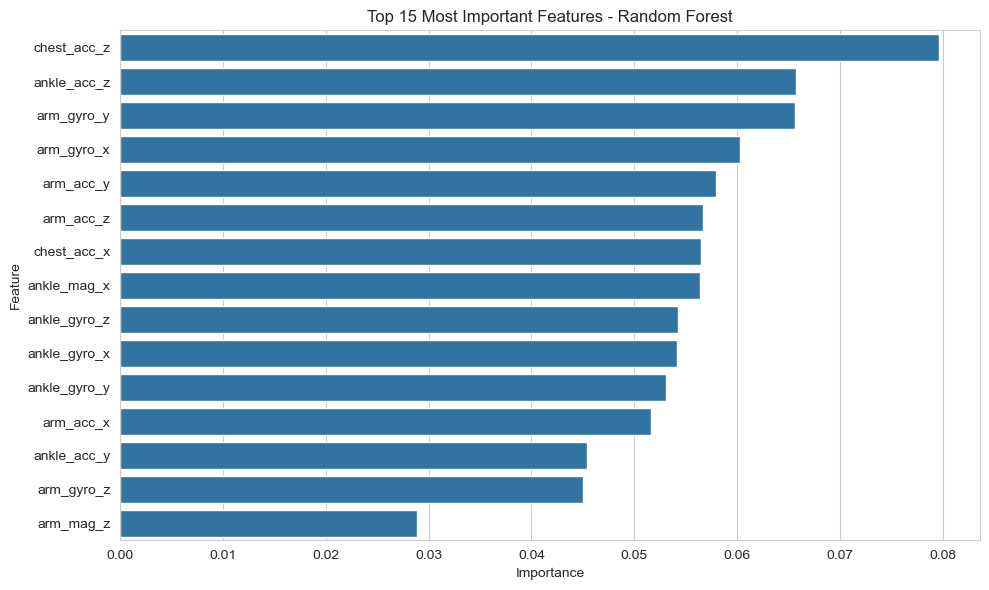

In [25]:
top_n = 15
top_features = feat_imp.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 15 Most Important Features - Random Forest")
plt.tight_layout()
plt.show()

### 23. Importance by sensor group

In [26]:
def get_sensor_group(feature):
    if feature.startswith("chest_acc"):
        return "Chest Accelerometer"
    elif feature.startswith("ecg"):
        return "ECG"
    elif feature.startswith("ankle_acc"):
        return "Ankle Accelerometer"
    elif feature.startswith("ankle_gyro"):
        return "Ankle Gyroscope"
    elif feature.startswith("ankle_mag"):
        return "Ankle Magnetometer"
    elif feature.startswith("arm_acc"):
        return "Arm Accelerometer"
    elif feature.startswith("arm_gyro"):
        return "Arm Gyroscope"
    elif feature.startswith("arm_mag"):
        return "Arm Magnetometer"
    else:
        return "Other"

feat_imp["Sensor_Group"] = feat_imp["Feature"].apply(get_sensor_group)

group_importance = (
    feat_imp.groupby("Sensor_Group")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(group_importance)

,Sensor_Group,Importance
0,Arm Gyroscope,0.170862
1,Arm Accelerometer,0.166220
2,Chest Accelerometer,0.163319
3,Ankle Gyroscope,0.161540
4,Ankle Accelerometer,0.131108
5,Ankle Magnetometer,0.101053
6,Arm Magnetometer,0.072611
7,Other,0.024434
8,ECG,0.008853


### 24. Sensor group importance plot

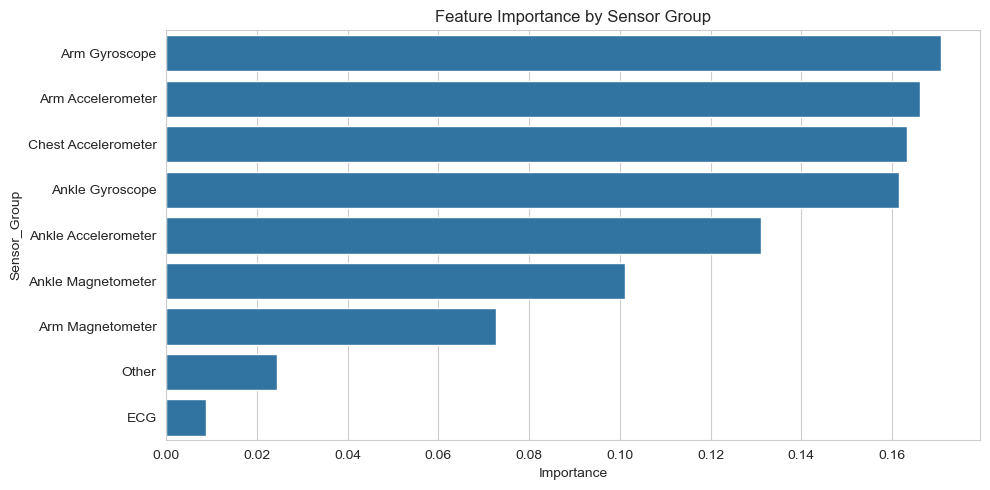

In [27]:
plt.figure(figsize=(10, 5))
sns.barplot(data=group_importance, x="Importance", y="Sensor_Group")
plt.title("Feature Importance by Sensor Group")
plt.tight_layout()
plt.show()

### 25. Import TensorFlow and Keras

In [28]:
!pip install tensorflow

In [29]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### 26. Prepare features for LSTM

In [30]:
# Use only sensor features, not label/activity/subject
feature_cols = [col for col in df_clean.columns if col not in ["label", "activity", "subject"]]

print("Number of sensor features:", len(feature_cols))
print(feature_cols)

Number of sensor features: 23
['chest_acc_x', 'chest_acc_y', 'chest_acc_z', 'ecg_1', 'ecg_2', 'ankle_acc_x', 'ankle_acc_y', 'ankle_acc_z', 'ankle_gyro_x', 'ankle_gyro_y', 'ankle_gyro_z', 'ankle_mag_x', 'ankle_mag_y', 'ankle_mag_z', 'arm_acc_x', 'arm_acc_y', 'arm_acc_z', 'arm_gyro_x', 'arm_gyro_y', 'arm_gyro_z', 'arm_mag_x', 'arm_mag_y', 'arm_mag_z']


### 27. Train/test split by subject

In [31]:
from sklearn.model_selection import GroupShuffleSplit

groups = df_clean["subject"]
X_base = df_clean[feature_cols]
y_base = df_clean["label"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_base, y_base, groups=groups))

train_df = df_clean.iloc[train_idx].copy()
test_df = df_clean.iloc[test_idx].copy()

print("Train subjects:", sorted(train_df["subject"].unique()))
print("Test subjects :", sorted(test_df["subject"].unique()))
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train subjects: [np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10)]
Test subjects : [np.int64(2), np.int64(9)]
Train shape: (273309, 26)
Test shape : (69886, 26)


### 28. Scale features using train data only

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_df.loc[:, feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df.loc[:, feature_cols] = scaler.transform(test_df[feature_cols])

print("Scaling done.")

Scaling done.


### 29. Function to create sliding windows

In [33]:
import numpy as np

def create_windows_by_subject(df, feature_cols, window_size=50, step_size=25):
    X_windows = []
    y_windows = []

    for subject in sorted(df["subject"].unique()):
        subject_df = df[df["subject"] == subject].copy()

        X_subject = subject_df[feature_cols].values
        y_subject = subject_df["label"].values

        for start in range(0, len(subject_df) - window_size + 1, step_size):
            end = start + window_size

            window_x = X_subject[start:end]
            window_y = y_subject[end - 1]  # label of last time step

            X_windows.append(window_x)
            y_windows.append(window_y)

    return np.array(X_windows), np.array(y_windows)

### 30. Create train and test windows

In [34]:
window_size = 50
step_size = 25

X_train_seq, y_train_seq = create_windows_by_subject(
    train_df, feature_cols, window_size=window_size, step_size=step_size
)

X_test_seq, y_test_seq = create_windows_by_subject(
    test_df, feature_cols, window_size=window_size, step_size=step_size
)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape :", X_test_seq.shape)
print("y_test_seq shape :", y_test_seq.shape)

X_train_seq shape: (10921, 50, 23)
y_train_seq shape: (10921,)
X_test_seq shape : (2793, 50, 23)
y_test_seq shape : (2793,)


### 31. Encode labels for LSTM

In [35]:
from tensorflow.keras.utils import to_categorical

# labels are 1 to 12, so shift to 0 to 11
y_train_seq_adj = y_train_seq - 1
y_test_seq_adj = y_test_seq - 1

num_classes = len(np.unique(y_train_seq_adj))
print("Number of classes:", num_classes)

y_train_cat = to_categorical(y_train_seq_adj, num_classes=num_classes)
y_test_cat = to_categorical(y_test_seq_adj, num_classes=num_classes)

print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape :", y_test_cat.shape)

Number of classes: 12
y_train_cat shape: (10921, 12)
y_test_cat shape : (2793, 12)


### 32. Build the LSTM model

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\mukta\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,004 (97.67 KB)

 Trainable params: 25,004 (97.67 KB)

 Non-trainable params: 0 (0.00 B)

### 33. Train the LSTM

In [37]:
history = model.fit(
    X_train_seq,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5185 - loss: 1.5565 - val_accuracy: 0.6604 - val_loss: 1.2569
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8186 - loss: 0.6178 - val_accuracy: 0.7222 - val_loss: 0.8523
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8955 - loss: 0.3654 - val_accuracy: 0.7378 - val_loss: 1.0593
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9414 - loss: 0.2437 - val_accuracy: 0.7982 - val_loss: 1.0131
Epoch 5/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9620 - loss: 0.1632 - val_accuracy: 0.8320 - val_loss: 0.8117
Epoch 6/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9712 - loss: 0.1388 - val_accuracy: 0.8545 - val_loss: 0.6563
Epoch 7/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9701 - loss: 0.1282 - val_accuracy: 0.8096 - val_loss: 1.1124
Epoch 8/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.9747 - loss: 0.1146 - val_accu

### 34. Evaluate the LSTM

In [38]:
test_loss, test_accuracy = model.evaluate(X_test_seq, y_test_cat, verbose=0)

print("LSTM Test Accuracy:", test_accuracy)
print("LSTM Test Loss:", test_loss)

LSTM Test Accuracy: 0.7200143337249756
LSTM Test Loss: 1.4288219213485718


### 35. LSTM predictions and classification report

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict(X_test_seq)
y_pred_lstm = np.argmax(y_pred_probs, axis=1) + 1   # shift back to 1-12
y_true_lstm = y_test_seq

print(classification_report(y_true_lstm, y_pred_lstm))

88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
              precision    recall  f1-score   support

           1       0.79      0.50      0.61       244
           2       0.20      0.01      0.02       246
           3       1.00      0.50      0.66       246
           4       0.88      1.00      0.93       246
           5       0.81      0.93      0.86       244
           6       0.62      0.87      0.73       242
           7       0.37      0.90      0.53       247
           8       0.81      0.68      0.74       256
           9       1.00      1.00      1.00       246
          10       0.75      0.85      0.80       246
          11       0.86      0.70      0.77       246
          12       0.82      0.71      0.76        84

    accuracy                           0.72      2793
   macro avg       0.74      0.72      0.70      2793
weighted avg       0.74      0.72      0.70      2793



### 35. LSTM confusion matrix

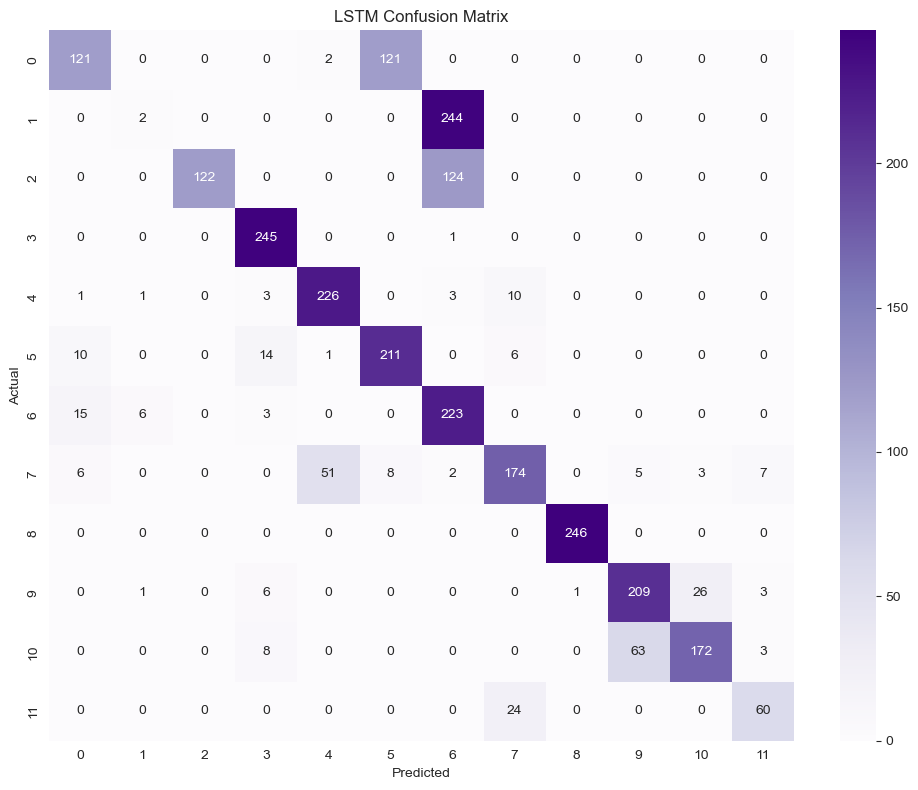

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Purples")
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### 36. Training history plot

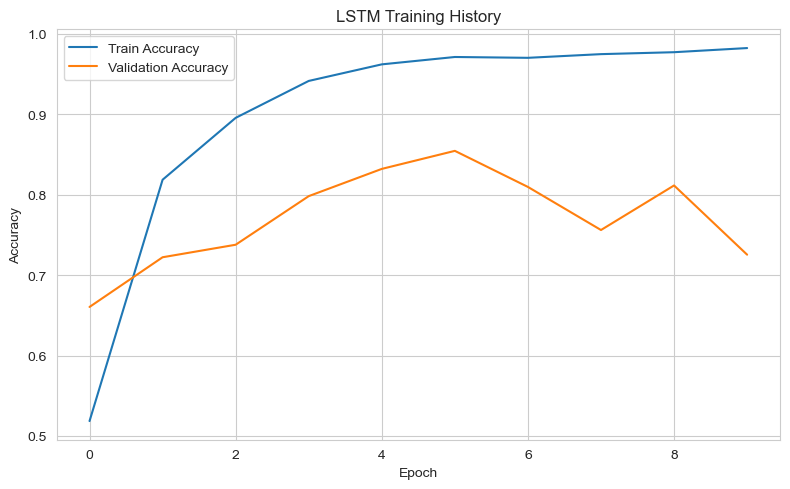

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### 37. Compare all three models

,Model,Accuracy
0,KNN,0.680151
1,Random Forest,0.787096
2,LSTM,0.720014


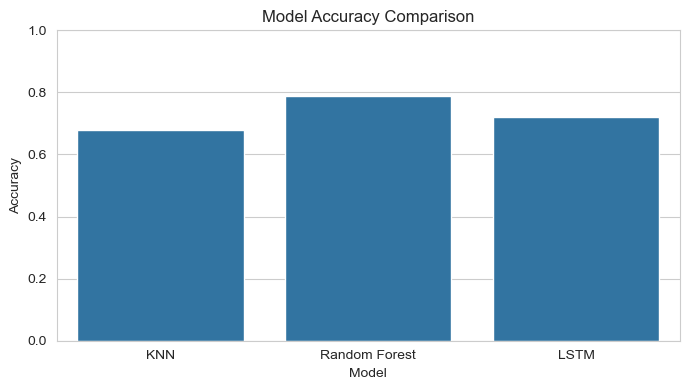

In [42]:
results_final = pd.DataFrame({
    "Model": ["KNN", "Random Forest", "LSTM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf),
        test_accuracy
    ]
})

display(results_final)

plt.figure(figsize=(7, 4))
sns.barplot(data=results_final, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Clean Confusion Matrix with Activity Names

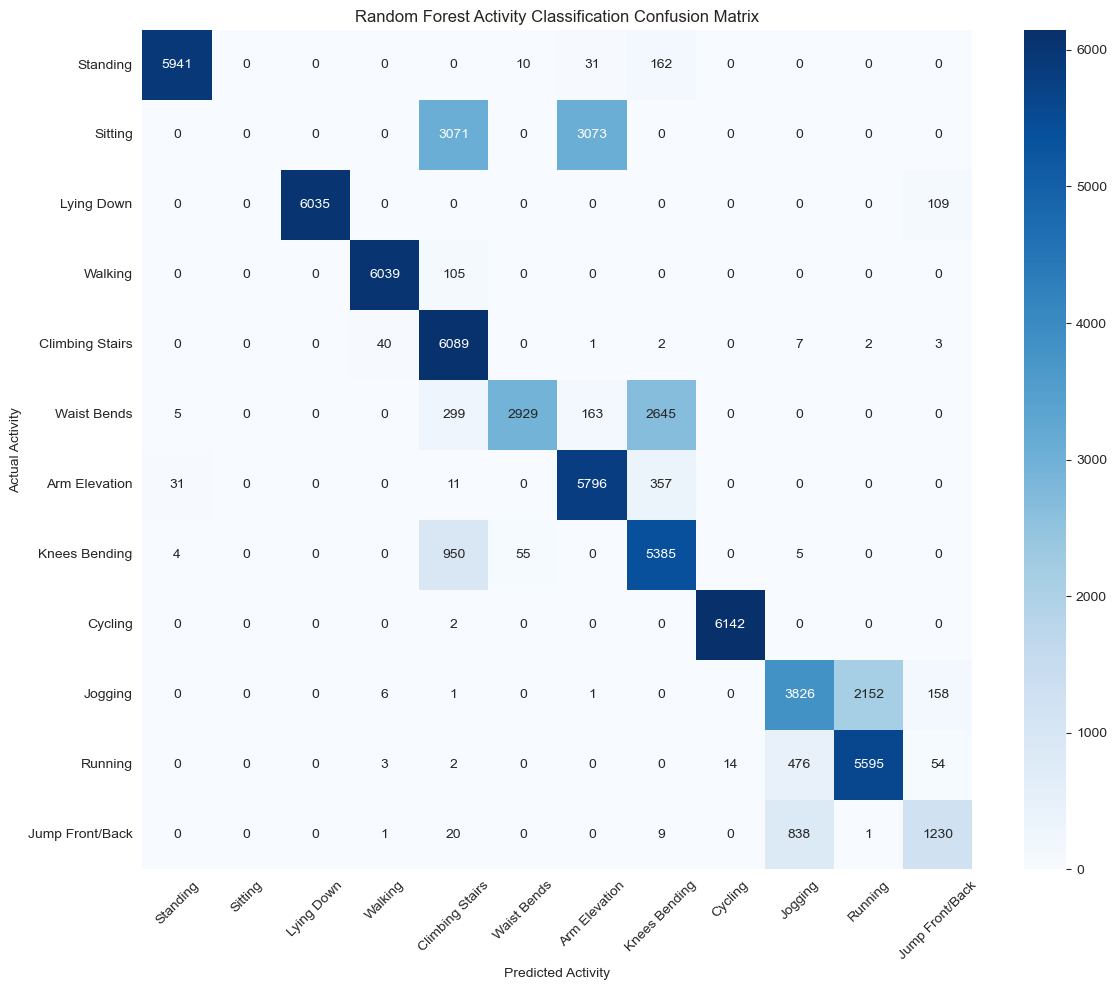

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

activity_labels = [
    "Standing",
    "Sitting",
    "Lying Down",
    "Walking",
    "Climbing Stairs",
    "Waist Bends",
    "Arm Elevation",
    "Knees Bending",
    "Cycling",
    "Jogging",
    "Running",
    "Jump Front/Back"
]

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=activity_labels,
    yticklabels=activity_labels
)

plt.title("Random Forest Activity Classification Confusion Matrix")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()